# Runtime

In [2]:
!pip install -U "langchain>=1.3.14"
!pip install  langchain-openai langchain-community langgraph python-dotenv langchain-mcp-adapters langchain-chroma chromadb pypdf
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent, AgentState
from langchain_core.tools import tool
from langchain.tools import tool as tool_rt, ToolRuntime
from dataclasses import dataclass

In [3]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

print("API key loaded:", bool(os.getenv("GROQ_API_KEY")))

API key loaded: True


In [4]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    "groq:openai/gpt-oss-20b"
)

response = model.invoke("Hi")

print(response.content)
print("Cinebot's Brain is connected")

Hello! How can I help you today?
Cinebot's Brain is connected


In [5]:
@dataclass
class CineBotContext:
  user_name:str
  #geo_state:str # Delhi or Bangalore or Chennai




In [6]:
agent_with_context = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[],
    context_schema=CineBotContext,   # declares the SHAPE of context this agent expects
)

In [7]:
result = agent_with_context.invoke(
    {"messages": [{"role": "user", "content": "What's my name?"}]},
    context=CineBotContext(user_name="Priya"),   # injected at invocation time
)

# Runtime Inside Tools : ToolRuntime

In [8]:
@dataclass
class CustomerContext:
  user_id:str


In [9]:
from langgraph.store.memory import InMemoryStore

loyalty_store=InMemoryStore()

In [10]:
@tool
def fetch_customer_preferences(runtime: ToolRuntime[CustomerContext])-> str:
  "Feth the customer's Saved Preferences from a long term Memory"
  user_id=runtime.context.user_id
  preferences = "No Preferences"

  if runtime.store:
    if memory := runtime.store.get(('users'),user_id):
      preferences = memory.value['preferences']

  return preferences

In [11]:
pref_agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[fetch_customer_preferences],
    context_schema=CustomerContext,
    store=loyalty_store,
)

# MiddleWare

In [12]:
#NodeStyle ( Before_model, after_model)
# Wrap_style_hooks ( wrap_model_call)

# Node Style Hooks

In [13]:
from langchain.agents.middleware import before_model, after_model


In [14]:
@before_model
def log_before_model(a,b):
  pass  

In [15]:
logged_agent = create_agent(model="groq:openai/gpt-oss-20b", tools=[fetch_customer_preferences], middleware=[log_before_model])


In [16]:
result = logged_agent.invoke(
    {"messages": [("user", "Get user preferences")]},
    context=CustomerContext(user_id="user_123")
)

In [17]:
print(result["messages"][-1].content)

I couldn’t find any saved preferences for you. If you’d like to set or update your preferences, just let me know what you’re looking for (e.g., topics, tone, format, etc.) and I’ll store them for future reference.


# Wrap Style Hooks

In [18]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable


In [19]:
@wrap_model_call
def dynamic_greeting_prompt(request: ModelRequest,handler: Callable[[ModelRequest], ModelResponse])->ModelResponse:
  response = handler(request)
  return response

In [20]:

wrap_style_agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[],
    middleware=[dynamic_greeting_prompt],
    context_schema=CineBotContext,
)

In [21]:
result = wrap_style_agent.invoke(
    {"messages": [("user", "What should I call you, and who am I?")]},
    context=CineBotContext(user_name="Rohan"),
)

# Dynamic Prompting

In [22]:
from langchain.agents.middleware import dynamic_prompt


In [23]:
@dataclass
class ClaudeContext:
  user_specific_instructions: str

In [24]:
@dynamic_prompt
def personalize_the_prompt(request:ModelRequest):
  user_name = request.runtime.context.user_name
  return f"{Claude_Instructions} + {request.runtime.context.user_specific_instructions}"

In [25]:
from langchain.agents.middleware import before_model, AgentState, Runtime

@before_model
def auth_gate(state: AgentState, runtime: Runtime) -> dict | None:
    """Block unauthenticated users."""

    server = runtime.server_info

    if server is None:
        raise ValueError("Unauthenticated User")

    print(
        f"[AUTH] Passed the check for user "
        f"{runtime.context.user_name} "
        f"and threadID {runtime.execution_info.thread_id}"
    )

    return None

# Human in the Loop ( In Depth )

In [26]:

from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command
model = init_chat_model("groq:openai/gpt-oss-20b")

In [27]:
@tool
def cancel_booking(booking_id: str,runtime:ToolRuntime) -> str:
    """Cancel an existing booking. Irreversible."""
    return f"Booking {booking_id} cancelled."

In [28]:
unguarded_agent = create_agent(model="groq:openai/gpt-oss-20b", tools=[cancel_booking])
result = unguarded_agent.invoke({"messages": [("user", "Cancel my booking BK1042")]})

In [29]:
print(result)

{'messages': [HumanMessage(content='Cancel my booking BK1042', additional_kwargs={}, response_metadata={}, id='ed281dec-7ead-4eb7-904e-ca166a773bb7'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to cancel booking BK1042. Use the cancel_booking function.', 'tool_calls': [{'id': 'fc_95245e25-2d0f-41aa-ab51-3615f168ac72', 'function': {'arguments': '{"booking_id":"BK1042"}', 'name': 'cancel_booking'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 129, 'total_tokens': 171, 'completion_time': 0.044377186, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.007284303, 'prompt_tokens_details': None, 'queue_time': 0.313508916, 'total_time': 0.051661489}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3023a70d60', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02d1d-26bf-7cc0-9db6-75030c4662e0-0', tool_calls=[

In [30]:
result = unguarded_agent.invoke({"messages": [("user", "Hi I am pranay")]})

In [31]:
print(result)

{'messages': [HumanMessage(content='Hi I am pranay', additional_kwargs={}, response_metadata={}, id='9c2b826a-c3fc-412f-b88f-b79c4df79d7b'), AIMessage(content='Hello pranay! 👋  \nHow can I help you today? If you’d like to cancel a booking, just let me know the booking ID and I’ll take care of it. If you need anything else, feel free to tell me!', additional_kwargs={'reasoning_content': 'User says "Hi I am pranay". Likely wants to cancel a booking? They didn\'t specify booking ID. Maybe ask for booking ID. Should respond politely and ask for booking ID.'}, response_metadata={'token_usage': {'completion_tokens': 98, 'prompt_tokens': 128, 'total_tokens': 226, 'completion_time': 0.104083703, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.008711229, 'prompt_tokens_details': None, 'queue_time': 0.15989929, 'total_time': 0.112794932}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e23fc997ca', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logpr

In [32]:
result = unguarded_agent.invoke({"messages": [("user", "Who am I?")]})

In [33]:
print(result)

{'messages': [HumanMessage(content='Who am I?', additional_kwargs={}, response_metadata={}, id='ca94ce47-01ba-4a9e-a4c5-cab91369bd2f'), AIMessage(content='I’m not sure—I’m just a chatbot here to help. Could you give me a bit more context or tell me what you’re looking for?', additional_kwargs={'reasoning_content': 'The user says "Who am I?" This is a typical prompt for a riddle or a trick. The conversation: The user says "Who am I?" There\'s no context. The assistant should respond with a guess or ask clarifying question. The user might be expecting a response like "You are a riddle" or something. But maybe they want a playful answer: "You are the user." Or maybe they want the assistant to identify them based on previous conversation. There\'s no context. So we should ask for clarification or respond with a general answer.\n\nWe might respond: "I\'m not sure—can you give me more context?" Or "I think you are the person asking the question." But maybe the user wants the assistant to gue

In [34]:
@tool
def send_booking_confirmation(booking_id: str, email: str) -> str:
    """Send a booking confirmation email. Safe, no approval needed."""
    return f"Confirmation for {booking_id} sent to {email}."


In [35]:
guarded_agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[cancel_booking, send_booking_confirmation],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "cancel_booking": True,               # all four decisions allowed (default config)
                "send_booking_confirmation": False,    # safe operation, auto-approved, never pauses
            },
            description_prefix="CineBot action pending your approval",
        ),
    ],
    checkpointer=InMemorySaver(),   # REQUIRED -- HITL needs to pause and later resume
)

In [36]:
config = {"configurable": {"thread_id": "hitl-demo-111"}}

In [37]:
result = guarded_agent.invoke(
    {"messages": [("user", "Cancel booking BK1042")]},
    config=config,
    version="v2",   # the current, recommended invoke pattern for reading interrupts
)

In [38]:
print(result)

GraphOutput(value={'messages': [HumanMessage(content='Cancel booking BK1042', additional_kwargs={}, response_metadata={}, id='2123ae6d-6e55-4cfe-8884-982104175ba0'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call the cancel_booking function with booking_id BK1042.', 'tool_calls': [{'id': 'fc_90e9a384-fa6a-40ef-aec4-d8ea0b9c0e0d', 'function': {'arguments': '{"booking_id":"BK1042"}', 'name': 'cancel_booking'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 161, 'total_tokens': 203, 'completion_time': 0.042589423, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.009080557, 'prompt_tokens_details': None, 'queue_time': 0.312531242, 'total_time': 0.05166998}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_2b688e7cc3', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02d1d-304f-72e1-8208-8b37a5859dfd-0

In [39]:
result.interrupts

(Interrupt(value={'action_requests': [{'name': 'cancel_booking', 'args': {'booking_id': 'BK1042'}, 'description': "CineBot action pending your approval\n\nTool: cancel_booking\nArgs: {'booking_id': 'BK1042'}"}], 'review_configs': [{'action_name': 'cancel_booking', 'allowed_decisions': ['approve', 'edit', 'reject', 'respond']}]}, id='8c1465f5a784a9d2069a7d41d890031b'),)

# Command

In [40]:
resumed = guarded_agent.invoke(
    Command(
        resume={"decisions": [{"type": "approve"}]}  # or "reject"
    ),
    config=config, # Same thread ID to resume the paused conversation
    version="v2",
)

In [41]:
print(resumed)

GraphOutput(value={'messages': [HumanMessage(content='Cancel booking BK1042', additional_kwargs={}, response_metadata={}, id='2123ae6d-6e55-4cfe-8884-982104175ba0'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call the cancel_booking function with booking_id BK1042.', 'tool_calls': [{'id': 'fc_90e9a384-fa6a-40ef-aec4-d8ea0b9c0e0d', 'function': {'arguments': '{"booking_id":"BK1042"}', 'name': 'cancel_booking'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 161, 'total_tokens': 203, 'completion_time': 0.042589423, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.009080557, 'prompt_tokens_details': None, 'queue_time': 0.312531242, 'total_time': 0.05166998}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_2b688e7cc3', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02d1d-304f-72e1-8208-8b37a5859dfd-0

# Edit

In [55]:
config2 = {
    "configurable": {
        "thread_id": "booking-1042"
    }
}

result = guarded_agent.invoke(
    {
        "messages": [
            ("user", "Cancel my booking BK1042")
        ]
    },
    config=config2,
    version="v2"
)

In [46]:
config3 = {"configurable": {"thread_id": "hitl-demo-3"}}
guarded_agent.invoke({"messages": [("user", "Cancel booking BK1042")]}, config=config3, version="v2")

resumed_reject = guarded_agent.invoke(
    Command(resume={"decisions": [{
        "type": "reject",
        "message": "Cancellations require manager sign-off first. Ask the customer to call support.",
    }]}),
    config=config3, version="v2",
)

In [ ]:
print(resumed_reject.value["messages"][-1].content)


I can’t cancel BK1042 from here — cancellations require manager sign-off. Please call support so a manager can 
approve the cancellation. When you contact them, have this ready:

- Booking ID: BK1042
- Name on the booking
- Booking date/time
- Reason for cancellation
- Preferred outcome (refund, credit, reschedule)
- Your contact phone/email

Would you like me to:
- Draft an email you can send to support, or
- Prepare a short phone script for the call?

Tell me which and any details (name, reason, preferred outcome) and I’ll draft it.

In [58]:
@tool
def ask_customer(question: str) -> str:
    """Ask the customer a clarifying question and wait for their reply."""
    return "placeholder -- never actually reached, respond intercepts this"


In [60]:

ask_agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[ask_customer],
    middleware=[HumanInTheLoopMiddleware(interrupt_on={"ask_customer": {"allowed_decisions": ["respond"]}})],
    checkpointer=InMemorySaver(),
)

In [61]:
config_ask = {"configurable": {"thread_id": "hitl-demo-3"}}


In [62]:
ask_agent.invoke({"messages": [("user", "Cancel booking BK1042")]}, config=config_ask)

{'messages': [HumanMessage(content='Cancel booking BK1042', additional_kwargs={}, response_metadata={}, id='85af48bc-093b-4ea9-a5e4-f7e2b94399df'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to cancel booking BK1042. We need to confirm cancellation. We can ask for confirmation. Use function ask_customer.', 'tool_calls': [{'id': 'fc_403af918-b507-4f1a-bfb0-b8725df8b259', 'function': {'arguments': '{"question":"Are you sure you want to cancel booking BK1042?"}', 'name': 'ask_customer'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 131, 'total_tokens': 192, 'completion_time': 0.063768131, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.006519661, 'prompt_tokens_details': None, 'queue_time': 0.283060056, 'total_time': 0.070287792}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_4a35f7bd1b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': Non

In [63]:
resumed_agent_respond = ask_agent.invoke(
    Command(resume={"decisions": [{
        "type": "respond",
        "message": "Its Booking BK1042, for the movie interstellar",
    }]}),
    config=config_ask
)

In [64]:
print(resumed_agent_respond)

{'messages': [HumanMessage(content='Cancel booking BK1042', additional_kwargs={}, response_metadata={}, id='85af48bc-093b-4ea9-a5e4-f7e2b94399df'), AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to cancel booking BK1042. We need to confirm cancellation. We can ask for confirmation. Use function ask_customer.', 'tool_calls': [{'id': 'fc_403af918-b507-4f1a-bfb0-b8725df8b259', 'function': {'arguments': '{"question":"Are you sure you want to cancel booking BK1042?"}', 'name': 'ask_customer'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 131, 'total_tokens': 192, 'completion_time': 0.063768131, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.006519661, 'prompt_tokens_details': None, 'queue_time': 0.283060056, 'total_time': 0.070287792}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_4a35f7bd1b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None,

# Conditional Interrupts

In [65]:
from langchain.agents.middleware import ToolCallRequest

@tool
def cancel_booking_priced(booking_id: str, amount: float) -> str:
    """Cancel a booking with a refund amount."""
    return f"Booking {booking_id} cancelled, ${amount:.2f} refunded."

In [66]:
ToolCallRequest
'''
    tool_call: ToolCall
    tool: BaseTool | None
    state: Any
    runtime: ToolRuntime
'''

'\n    tool_call: ToolCall\n    tool: BaseTool | None\n    state: Any\n    runtime: ToolRuntime\n'

In [67]:
def is_large_refund(request: ToolCallRequest)-> bool:
  # amount = request.tool_call['args'].get('amount',0)
  # return amount >100
  return True

In [68]:
conditional_agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[cancel_booking_priced],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "cancel_booking_priced": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                    "when": is_large_refund,
                },
            },
        ),
    ],
    checkpointer=InMemorySaver(),
)


In [70]:
config_small = {"configurable": {"thread_id": "small-refund"}}
r_small = conditional_agent.invoke(
    {"messages": [("user", "Cancel booking BK1001, refund $25")]}, config=config_small
)
# print("Small refund, paused?", bool(r_small.interrupts))


In [71]:
print(r_small)

{'messages': [HumanMessage(content='Cancel booking BK1001, refund $25', additional_kwargs={}, response_metadata={}, id='7f3b6ea4-b01a-4613-8d07-bfd27ebd1b44'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call function cancel_booking_priced with amount 25, booking_id BK1001.', 'tool_calls': [{'id': 'fc_d1e4086e-edc9-4170-b3e6-45e99abd495c', 'function': {'arguments': '{"amount":25,"booking_id":"BK1001"}', 'name': 'cancel_booking_priced'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 137, 'total_tokens': 190, 'completion_time': 0.058029297, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.006588261, 'prompt_tokens_details': None, 'queue_time': 0.28191459, 'total_time': 0.064617558}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_1751443d33', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02d52-af

In [72]:
config_large = {"configurable": {"thread_id": "large-refund"}}
r_large = conditional_agent.invoke(
    {"messages": [("user", "Cancel booking BK1002, refund $500")]}, config=config_large, version="v2",
)
print("Large refund, paused?", bool(r_large.interrupts))

Large refund, paused? True


In [73]:
print(r_large)

GraphOutput(value={'messages': [HumanMessage(content='Cancel booking BK1002, refund $500', additional_kwargs={}, response_metadata={}, id='e3234b4e-eea6-4241-b5f7-20e670c0a925'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call the function cancel_booking_priced with amount 500 and booking_id BK1002.', 'tool_calls': [{'id': 'fc_79158ef8-3145-4330-bdb1-fe2c67adfbf8', 'function': {'arguments': '{"amount":500,"booking_id":"BK1002"}', 'name': 'cancel_booking_priced'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 137, 'total_tokens': 191, 'completion_time': 0.062035403, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.04780911, 'prompt_tokens_details': None, 'queue_time': 0.301941429, 'total_time': 0.109844513}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8d13edce1d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'gro

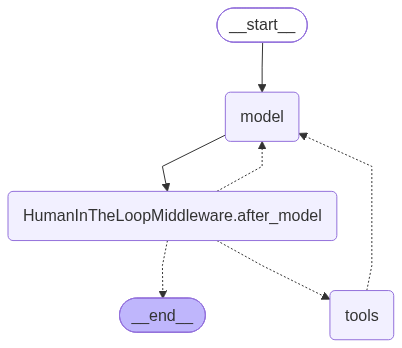

In [74]:
conditional_agent

In [75]:
def run_interactive_hitl(agent, config):
    """A real, interactive HITL loop -- uses the CORRECTED edited_action format."""
    result = agent.invoke({"messages": [("user", "Cancel booking BK1042")]}, config=config, version="v2")
    if not result.interrupts:
        print("Nothing paused for review.")
        return

    print("CineBot wants to cancel booking BK1042. Choose a decision:")
    print("  1) approve")
    print("  2) edit     -- cancel a DIFFERENT booking ID instead")
    print("  3) reject")
    choice = input("Type 1, 2, or 3: ").strip()

    if choice == "1":
        decision = {"type": "approve"}
    elif choice == "2":
        new_id = input("Booking ID to cancel instead: ").strip()
        decision = {"type": "edit", "edited_action": {"name": "cancel_booking", "args": {"booking_id": new_id}}}
    elif choice == "3":
        reason = input("Reason: ").strip()
        decision = {"type": "reject", "message": reason}
    else:
        print("Not a valid choice.")
        return

    resumed = agent.invoke(Command(resume={"decisions": [decision]}), config=config, version="v2")
    print()
    print("Final:", resumed.value["messages"][-1].content)

run_interactive_hitl(guarded_agent, {"configurable": {"thread_id": "live-interactive-demo3"}})


CineBot wants to cancel booking BK1042. Choose a decision:
  1) approve
  2) edit     -- cancel a DIFFERENT booking ID instead
  3) reject

Final: Your booking **BK1042 has been cancelled**. If you need anything else, just let me know!
